# Week 3 — Exploratory Data Analysis (EDA) on ADS-B Flight Data

In this assignment you'll explore a real-world dataset of **ADS-B aircraft position reports** collected by the [Wingbits](https://wingbits.com/) network. Every commercial (and many private) aircraft continuously broadcasts its position, altitude, speed, and identity. Ground stations receive these broadcasts, and this file is one hour of those messages.

The data is **pre-filtered it to a 200-mile radius around Lynchburg, VA** and saved it as a compact CSV, `lynchburg_adsb.csv` (~284k rows). That keeps it small enough to load in one line and explore comfortably on a laptop.

**Your goals for this assignment:**
1. Set up a clean Python environment (instructions below).
2. Open the `lynchburg_adsb.csv` data file and load it into a pandas `DataFrame`.
3. Study the example visualization we provide.
4. **Produce three visualizations of your own** to become familiar with the dataset (see the final section).

Work through the cells top to bottom. Read the notes — they explain *why*, not just *how*.

## 0. Before you start — create your own branch

You'll do your work on your **own git branch**, never directly on `main`. That keeps everyone's work separate until it's reviewed and merged.

Open a terminal at the **repository root** (the folder that contains `pyproject.toml`) and run:

```bash
# start from an up-to-date main
git checkout main
git pull

# create and switch to your own branch (use your name)
git checkout -b eda/your-name
```

Your editor/prompt should now show you're on `eda/your-name`. Do all your work here — you'll commit and push it at the end (see the final section).

## 1. Set up a Python virtual environment

A **virtual environment** ("venv") is an isolated copy of Python with its own installed packages. It keeps this project's dependencies separate from everything else on your computer, so upgrading a package for one project can never break another. Always use one per project.

Open a terminal at the **repository root** (the folder that contains `pyproject.toml`) and run the commands for your operating system.

### Windows (PowerShell)
```powershell
# 1. Create the virtual environment (a folder named .venv)
python -m venv .venv

# 2. Activate it (your prompt will show "(.venv)" once active)
.\.venv\Scripts\Activate.ps1

# 3. Upgrade pip, then install this project's EDA packages + a notebook kernel
python -m pip install --upgrade pip
pip install ".[eda]" ipykernel
```

### macOS / Linux (bash or zsh)
```bash
# 1. Create the virtual environment
python3 -m venv .venv

# 2. Activate it
source .venv/bin/activate

# 3. Upgrade pip, then install this project's EDA packages + a notebook kernel
python -m pip install --upgrade pip
pip install ".[eda]" ipykernel
```

`.[eda]` installs `pandas`, `pyarrow`, and `matplotlib` (declared in `pyproject.toml`); `ipykernel` lets Jupyter / VS Code run code inside this venv.

### Connect the environment to this notebook
- **VS Code:** open `example_eda.ipynb`, click the **kernel picker** in the top-right, and select the interpreter at `.venv`.
- **Classic Jupyter / JupyterLab:** register the venv as a kernel, then pick "SkyWatch EDA" from the kernel menu:
```bash
python -m ipykernel install --user --name skywatch-eda --display-name "SkyWatch EDA"
```

When you're set up, run the next cell. If it prints version numbers with no errors, you're ready.

In [16]:
# Confirm the environment is working. If any import fails, revisit Section 1.
import sys
import pandas as pd
import matplotlib.pyplot as plt

print("Python :", sys.version.split()[0])
print("pandas :", pd.__version__)

# Show plots inline in the notebook
%matplotlib inline

Python : 3.14.7
pandas : 3.0.5


## 2. About the dataset

The file `lynchburg_adsb.csv` holds **~284,000 position reports** (rows) with **53 columns**, all from a single hour: **2026-09-01, 00:00-01:00 UTC**, within **200 miles of Lynchburg, VA** (37.41°N, -79.14°W).

Each row is one aircraft reporting where it was at one instant. The same aircraft appears many times (once every few seconds), so you can reconstruct flight paths.

The column names are terse ADS-B field codes. Here are the ones you'll use most:

| Column | Meaning | Units / notes |
|--------|---------|---------------|
| `timestamp` | Time of the report | UTC, millisecond precision |
| `h` | ICAO 24-bit address | Unique hex id per aircraft (e.g. `a4794e`) |
| `f` | Flight / callsign | e.g. `DAL2993` (Delta 2993) |
| `la`, `lo` | Latitude, Longitude | Decimal degrees |
| `ab` | Barometric altitude | Feet |
| `ag` | Geometric (GPS) altitude | Feet |
| `gs` | Ground speed | Knots |
| `tr` | Track over ground | Degrees (0 = North, 90 = East) |
| `th` | True heading | Degrees |
| `gr` | Geometric vertical rate | Feet per minute (+climb / -descend) |
| `br` | Barometric vertical rate | Feet per minute |
| `sq` | Squawk | 4-digit transponder code |
| `c` | Emitter category | Size/type class: `A1` light ... `A5` heavy, `B*` gliders/balloons, `C*` ground/other |
| `og` | On ground | `True` if the aircraft is on the ground |
| `t` | Message source type | e.g. `adsb_icao`, `mlat`, `tisb` |
| `link` | External info link | Often empty |

The remaining columns are advanced receiver / signal-quality fields (accuracy, integrity, weather) - explore them later if you're curious.


## 3. Peek at the file *before* loading it

Even though this file is small, it's good practice to inspect a dataset's structure **first** — the column names and a few example rows — before pulling the whole thing into memory. The cell below reads just the first few rows.

In [17]:
from pathlib import Path

# The CSV lives in the repo root, one level up from this notebooks/ folder.
# Try both locations so it works whether the kernel's working directory is the
# repo root or the notebooks/ folder.
CSV_PATH = Path("lynchburg_adsb.csv")
if not CSV_PATH.exists():
    CSV_PATH = Path("..") / "data" / "lynchburg_adsb.csv"

# Read only the first few rows to see the structure without loading everything.
preview = pd.read_csv(CSV_PATH, nrows=5)
print(f"Columns    : {preview.shape[1]}")
print("\nAll column names:")
print(list(preview.columns))
preview

Columns    : 53

All column names:
['ab', 'ag', 'c', 'd', 'f', 'gr', 'gs', 'gv', 'h', 'la', 'lo', 'n', 'nb', 'np', 'nv', 'ra', 'rc', 'rs', 's', 'sq', 'st', 'th', 'timestamp', 'tr', 'v', 'm', 'i', 'mh', 'trr', 'ro', 'br', 'em', 'nq', 'nam', 'naf', 'nh', 'nm', 'sp', 'a', 'spi', 'wd', 'ws', 'oat', 'tat', 'rds', 'rdi', 'sda', 'ct', 'gpb', 'sn', 'og', 't', 'link']


,ab,ag,c,d,f,gr,gs,gv,h,la,...,tat,rds,rdi,sda,ct,gpb,sn,og,t,link
0,4850,5200,A3,unknown,AAL1715,NaN,186.7,2,ace81d,34.945816,...,NaN,NaN,NaN,2,NaN,NaN,0.0,False,adsb_icao,NaN
1,1750,1875,A2,unknown,PDT6098,NaN,134.3,2,a8d6bd,35.140091,...,NaN,NaN,NaN,2,NaN,NaN,0.0,False,adsb_icao,NaN
2,35975,38200,A3,unknown,JIA5582,-128.0,472.8,2,a7e9e7,37.231567,...,NaN,NaN,NaN,2,NaN,NaN,0.0,False,adsb_icao,NaN
3,18225,19300,A3,unknown,AAL2794,NaN,379.9,2,a0541b,35.316017,...,NaN,NaN,NaN,2,NaN,NaN,0.0,False,adsb_icao,NaN
4,3425,3650,A3,unknown,TAP233,NaN,219.0,2,495307,39.146805,...,NaN,NaN,NaN,3,NaN,NaN,0.0,False,adsb_icao,NaN


## 4. Load the data into a pandas DataFrame

This file is small enough (~284k rows) to load entirely in one line. One good habit still applies: **load only the columns you need** (`usecols=...`) — it's faster and keeps the DataFrame tidy while you explore.

Run the cell below to load the columns from the table in Section 2. The optional cell after it loads **every** column.

In [18]:
# The columns we'll work with. Add or remove as you explore (see the table in Section 2).
USE_COLS = ["timestamp", "h", "f", "la", "lo", "ab", "ag", "gs", "tr", "gr", "sq", "c", "og", "t"]

# --- Load the columns we need ----------------------------------------------
df = pd.read_csv(CSV_PATH, usecols=USE_COLS)

# Parse the timestamp text into real datetime values (handy for time-based plots).
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

print(f"Loaded {len(df):,} rows x {df.shape[1]} columns")
df.head()

Loaded 284,476 rows x 14 columns


,ab,ag,c,f,gr,gs,h,la,lo,sq,timestamp,tr,og,t
0,4850.0,5200,A3,AAL1715,NaN,186.7,ace81d,34.945816,-80.945136,NaN,2026-09-01 00:25:40.236000+00:00,4.920000,False,adsb_icao
1,1750.0,1875,A2,PDT6098,NaN,134.3,a8d6bd,35.140091,-80.960102,NaN,2026-09-01 00:25:40.257000+00:00,356.160004,False,adsb_icao
2,35975.0,38200,A3,JIA5582,-128.0,472.8,a7e9e7,37.231567,-80.600086,NaN,2026-09-01 00:25:40.267000+00:00,238.929993,False,adsb_icao
3,18225.0,19300,A3,AAL2794,NaN,379.9,a0541b,35.316017,-80.046562,2575.0,2026-09-01 00:25:40.287000+00:00,70.470001,False,adsb_icao
4,3425.0,3650,A3,TAP233,NaN,219.0,495307,39.146805,-77.456778,NaN,2026-09-01 00:25:40.288000+00:00,180.779999,False,adsb_icao


In [19]:
# --- (Optional) Load EVERY column -----------------------------------------
# The file is small, so this is fine too. Use it when you want to explore the
# advanced receiver / signal-quality fields not listed in Section 2.
#
# df = pd.read_csv(CSV_PATH)
# print(f"Loaded {len(df):,} rows x {df.shape[1]} columns")

### A first look
Before plotting anything, get a feel for the data: its shape, data types, missing values, and the range of numeric columns. This is the heart of EDA.

In [20]:
# Data types and non-null counts for each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284476 entries, 0 to 284475
Data columns (total 14 columns):
 #   Column     Non-Null Count   Dtype              
---  ------     --------------   -----              
 0   ab         271040 non-null  float64            
 1   ag         284476 non-null  int64              
 2   c          284032 non-null  str                
 3   f          283635 non-null  str                
 4   gr         38272 non-null   float64            
 5   gs         284353 non-null  float64            
 6   h          284476 non-null  str                
 7   la         284476 non-null  float64            
 8   lo         284476 non-null  float64            
 9   sq         95988 non-null   float64            
 10  timestamp  284190 non-null  datetime64[us, UTC]
 11  tr         284235 non-null  float64            
 12  og         284476 non-null  bool               
 13  t          284476 non-null  str                
dtypes: bool(1), datetime64[us, UTC](1), float64(7),

In [21]:
# Summary statistics for the numeric columns
df.describe()

,ab,ag,gr,gs,la,lo,sq,tr
count,271040.000000,284476.000000,38272.000000,284353.000000,284476.000000,284476.000000,95988.000000,284235.000000
mean,14658.265570,14814.964268,24.547659,300.863166,37.412690,-78.745948,3696.560758,168.537751
std,12713.190622,13566.828518,1118.835177,125.451945,1.605228,1.689458,2117.177353,107.299000
min,-200.000000,-475.000000,-20736.000000,0.000000,34.520828,-82.784963,114.000000,0.000000
25%,4300.000000,4025.000000,-256.000000,221.800000,35.820494,-80.354977,2132.000000,66.500000
50%,8825.000000,8825.000000,0.000000,288.200000,37.598308,-78.477770,3321.000000,176.509995
75%,26550.000000,26800.000000,64.000000,428.100000,38.917431,-77.341284,5644.000000,256.519989
max,45050.000000,47225.000000,17344.000000,1912.700000,40.306412,-75.500443,7477.000000,359.880005


In [22]:
# How many DISTINCT aircraft are in this subset? (each is one ICAO hex address)
print(f"Distinct aircraft : {df['h'].nunique():,}")
print(f"Time span         : {df['timestamp'].min()}  ->  {df['timestamp'].max()}")
print(f"On the ground     : {(df['og'] == True).sum():,} reports")

Distinct aircraft : 915
Time span         : 2026-09-01 00:00:00.014000+00:00  ->  2026-09-01 00:59:59.990000+00:00
On the ground     : 5,269 reports


## 5. Example visualization: air traffic around Lynchburg

Each report has a latitude (`la`) and longitude (`lo`), so if we scatter longitude on the x-axis and latitude on the y-axis, **the region's flight corridors draw themselves**. We'll color each point by its altitude (`ab`) to separate high-altitude traffic crossing the area from lower aircraft near airports, and mark Lynchburg itself.

Study how this plot is built - you'll reuse the same pattern (filter -> plot -> label) for your own visualizations.

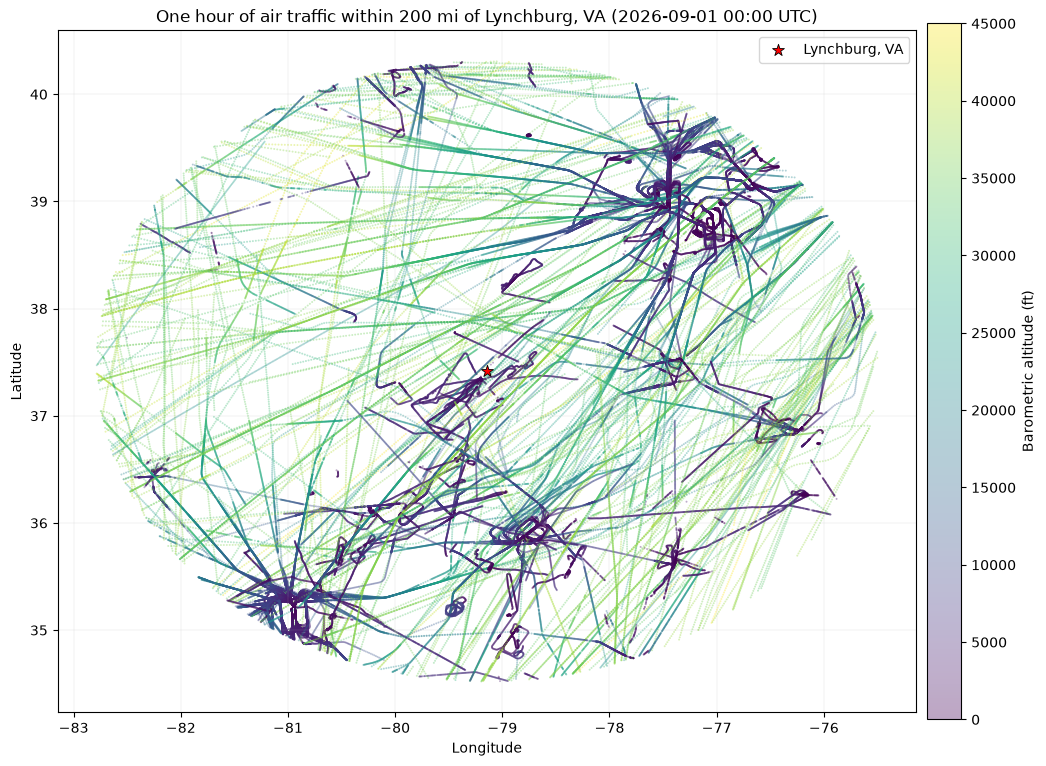

In [23]:
# 1. Filter to clean, airborne points with a sensible altitude range
air = df[df["og"] == False].dropna(subset=["la", "lo", "ab"])
air = air[(air["ab"] >= 0) & (air["ab"] <= 45000)]

# 2. Plot longitude vs latitude, colored by altitude
fig, ax = plt.subplots(figsize=(11, 9))
sc = ax.scatter(
    air["lo"], air["la"],
    c=air["ab"], cmap="viridis",
    s=2, alpha=0.35, linewidths=0,
)

# Mark Lynchburg, VA (the center of the 200-mile filter)
LYH_LAT, LYH_LON = 37.4138, -79.1422
ax.scatter([LYH_LON], [LYH_LAT], c="red", s=80, marker="*",
           edgecolors="black", linewidths=0.6, zorder=5, label="Lynchburg, VA")
ax.legend(loc="upper right")

# 3. Label everything (a plot without labels is not finished!)
cbar = fig.colorbar(sc, ax=ax, shrink=0.8, pad=0.01)
cbar.set_label("Barometric altitude (ft)")
ax.set_title("One hour of air traffic within 200 mi of Lynchburg, VA (2026-09-01 00:00 UTC)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
ax.grid(True, linewidth=0.3, alpha=0.4)
plt.tight_layout()
plt.show()

**What to notice:** straight lines are high-altitude airways crossing the region; clusters and lower-altitude points mark approaches to nearby airports (e.g. Roanoke, Richmond, Charlotte, DC-area fields). Coverage also depends on where Wingbits receivers are located, so gaps aren't necessarily empty sky.

---

## 6. Your turn - build three visualizations

Create **three** visualizations of your own to get familiar with the dataset. Add a new code cell for each (and a short markdown note saying what it shows and one thing you learned). Here are three prompts to get you started - do these or invent your own:

1. **Altitude distribution.** Plot a histogram of barometric altitude (`ab`) for airborne aircraft. Where do most aircraft fly? Do you see a spike at common cruising altitudes?
   - *Hint:* `air["ab"].plot.hist(bins=50)` or `plt.hist(...)`.

2. **Busiest operators.** The first 3 letters of a callsign (`f`) are the airline code (e.g. `DAL` = Delta, `UAL` = United). Make a bar chart of the 15 most common airline codes.
   - *Hint:* `df["f"].dropna().str[:3].value_counts().head(15).plot.bar()`.

3. **Speed vs. altitude.** Make a scatter plot of ground speed (`gs`) against altitude (`ab`). Is there a relationship? What might explain the shape?
   - *Hint:* start from the `air` DataFrame and reuse the scatter pattern above.

**Ideas for going further:** aircraft counts over time using `timestamp`; zoom the map to a single airport near Lynchburg (filter `la`/`lo`); the mix of emitter categories (`c`); or trace a single aircraft's path by filtering on one `h` value and plotting its `lo`/`la` points in time order.

For every plot: give it a **title** and **axis labels**, and filter out missing/nonsensical values first. Have fun exploring!

In [24]:
# Visualization 1 - your code here


In [25]:
# Visualization 2 - your code here


In [26]:
# Visualization 3 - your code here


## 7. Submit your work — commit & push

Once your three visualizations are filled in and the notebook runs top to bottom, save it. Then, from the **repository root**, commit your work to the branch you made in Section 0 and push it:

```bash
# (recommended) confirm the notebook runs cleanly first:
#   in the notebook, use  Kernel -> Restart & Run All

# stage the notebook (add any other files you changed)
git add notebooks/example_eda.ipynb

# commit with a short message describing what you did
git commit -m "EDA: your-name week 3 visualizations"

# push your branch to GitHub (the first push needs -u to set the upstream)
git push -u origin eda/your-name
```

Then open a **Pull Request** on GitHub from `eda/your-name` into `main` so a teammate can review and merge it. See [docs/CONTRIBUTING.md](../docs/CONTRIBUTING.md) for the review checklist.